In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [2]:
df=pd.read_csv(r"C:\Users\DELL\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [9]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
df['senior_tenure'] = df['SeniorCitizen'] * df['tenure']

In [13]:
df['charges_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)

In [15]:
df = df.drop(['MonthlyCharges','SeniorCitizen','customerID'], axis=1)

In [17]:
num_cols=df.select_dtypes(exclude='object').columns
cat_cols=df.select_dtypes(include='object').columns

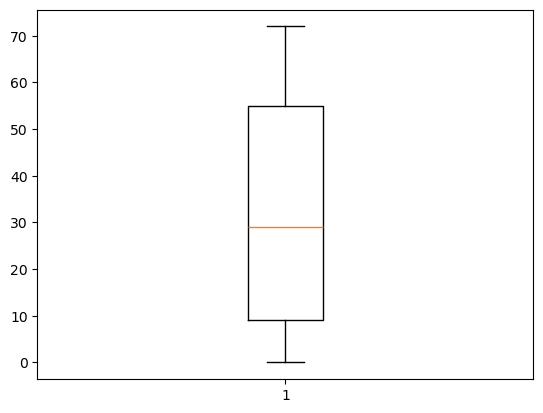

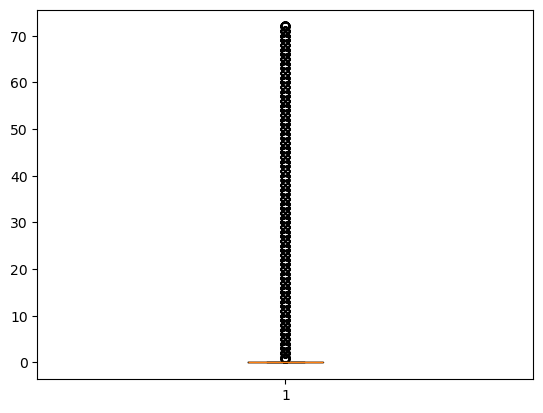

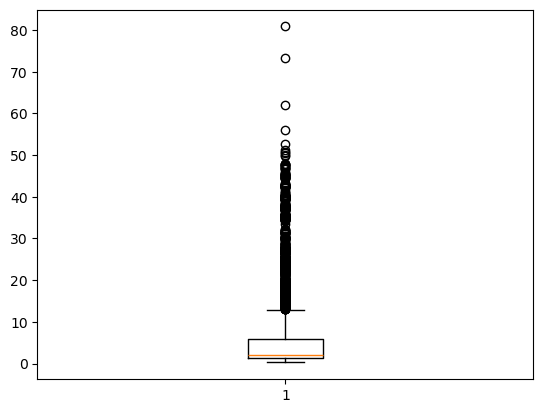

In [19]:
import matplotlib.pyplot as plt
for col in num_cols:
    plt.boxplot(df[col])
    plt.show()

<Axes: >

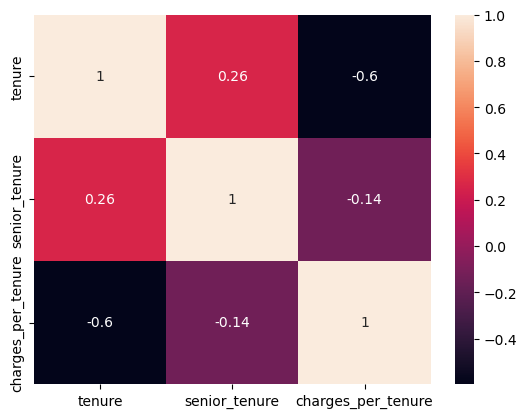

In [20]:
import seaborn as sns
num=df.select_dtypes(exclude='object')
cor=num.corr()
sns.heatmap(cor,annot=True)

The Heatmap shows that there is no any strong linear relationship so there is no multicollinearity problem, so it is good for our ML project.

In [24]:
x=df.drop('Churn',axis=1)
y=df['Churn']

In [26]:
y=y.map({'Yes':1,'No':0})

In [28]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [30]:
num_col=x.select_dtypes(exclude='object').columns
cat_col=x.select_dtypes(include='object').columns

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
num_pipeline=Pipeline([('Imputer',SimpleImputer(strategy='median')),
                      ('Scaler',StandardScaler())])

In [34]:
cat_pipeline=Pipeline([('Imputer',SimpleImputer(strategy='most_frequent')),
                      ('Encoder',OneHotEncoder(handle_unknown='ignore'))])

In [36]:
preprocessor=ColumnTransformer([('num',num_pipeline,num_col),
                               ('cat',cat_pipeline,cat_col)])

In [38]:
model_pipeline=Pipeline([('Transformer',preprocessor),
                        ('model',LogisticRegression(class_weight='balanced',max_iter=20000))])
model_pipeline

Pipeline(steps=[('Transformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Scaler',
                                                                   StandardScaler())]),
                                                  Index(['tenure', 'senior_tenure', 'charges_per_tenure'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TotalCharges'],
      dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=20000))])

In [40]:
model_pipeline.fit(x_train,y_train)

Pipeline(steps=[('Transformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Scaler',
                                                                   StandardScaler())]),
                                                  Index(['tenure', 'senior_tenure', 'charges_per_tenure'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TotalCharges'],
      dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=20000))])

In [42]:
y_pred=model_pipeline.predict(x_test)

In [44]:
from sklearn.metrics import precision_score,recall_score,f1_score,roc_auc_score
precision_score(y_test,y_pred)

0.5617760617760618

In [46]:
recall_score(y_test,y_pred)

0.7801608579088471

In [48]:
from sklearn.model_selection import cross_val_score,StratifiedKFold,GridSearchCV
fold=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cross=cross_val_score(model_pipeline,x,y,cv=fold,scoring='roc_auc')
cross

array([0.86010618, 0.84762071, 0.86039164, 0.8334214 , 0.83904597])

In [49]:
cross.mean()

0.8481171791285254

In [52]:
params={
    'model__C':[0.1,0.01,0.3,10,0.6,0.2],
    'model__penalty':['l2']
}
grid=GridSearchCV(model_pipeline,params,cv=5,scoring='roc_auc')
grid.fit(x_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('Transformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('Imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('Scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['tenure', 'senior_tenure', 'charges_per_tenure'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('Imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('Encoder',
                                                                                          OneH...
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TotalCharges'],
      dtype='object'))])),
                                       ('model',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=20000))]),
             param_grid={'model__C': [0.1, 0.01, 0.3, 10, 0.6, 0.2],
                         'model__penalty': ['l2']},
             scoring='roc_auc')

In [53]:
grid.best_params_

{'model__C': 0.6, 'model__penalty': 'l2'}

In [54]:
grid.best_score_

0.8447489816209902

In [55]:
y_prob=model_pipeline.predict_proba(x_test)[:,1]
y_pred_new=(y_prob>=0.4).astype('int')

In [56]:
precision_score(y_test,y_pred_new)

0.49608763693270735

In [57]:
recall_score(y_test,y_pred_new)

0.8498659517426274

In [58]:
f1_score(y_test,y_pred_new)

0.6264822134387352

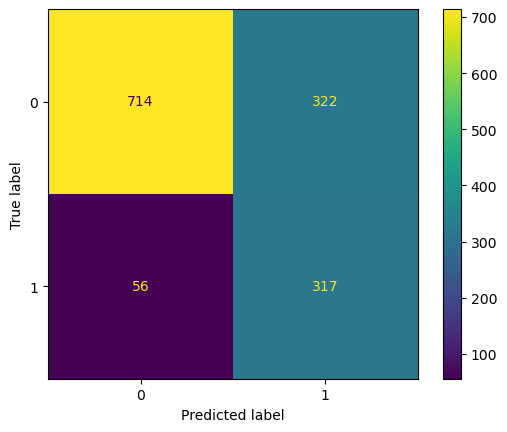

In [66]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm=confusion_matrix(y_test,y_pred_new)
ConfusionMatrixDisplay(cm).plot()
plt.show()

The model correctly identifies 308 churn customers, while missing only 65 churn cases.
The recall is 82%, meaning the model successfully detects most customers likely to churn.
Although precision is lower (51%), this is acceptable because companies prefer to target more customers for retention campaigns rather than miss potential churners.